In [0]:
# PHASE 1: BRONZE LAYER (RAW DATA INGESTION)
# Load unmodified raw retail supply chain CSV datasets directly into the Databricks environment from Unity Catalog Volumes.
df_orders = spark.read.csv("/Volumes/workspace/default/retail_data/Smart Metadata-Driven Retail Supply Chain Pipeline/Smart Metadata-Driven Retail Supply Chain Pipeline/orders.csv", header=True, inferSchema=True)
df_inventory = spark.read.csv("/Volumes/workspace/default/retail_data/Smart Metadata-Driven Retail Supply Chain Pipeline/Smart Metadata-Driven Retail Supply Chain Pipeline/inventory_.csv", header=True, inferSchema=True)
df_products = spark.read.csv("/Volumes/workspace/default/retail_data/Smart Metadata-Driven Retail Supply Chain Pipeline/Smart Metadata-Driven Retail Supply Chain Pipeline/products.csv", header=True, inferSchema=True)
df_stores = spark.read.csv("/Volumes/workspace/default/retail_data/Smart Metadata-Driven Retail Supply Chain Pipeline/Smart Metadata-Driven Retail Supply Chain Pipeline/stores.csv", header=True, inferSchema=True)
df_suppliers = spark.read.csv("/Volumes/workspace/default/retail_data/Smart Metadata-Driven Retail Supply Chain Pipeline/Smart Metadata-Driven Retail Supply Chain Pipeline/suppliers.csv", header=True, inferSchema=True)

print("Orders:", df_orders.count())
print("Inventory:", df_inventory.count())
print("Products:", df_products.count())
print("Stores:", df_stores.count())
print("Suppliers:", df_suppliers.count())

print("Bronze Ingestion Successful!")
display(df_orders.limit(5))



Orders: 600
Inventory: 300
Products: 30
Stores: 10
Suppliers: 20
Bronze Ingestion Successful!


order_id,product_id,store_id,quantity,price,order_date
ORD-0001,PROD-018,STR-04,15,364.81,2024-01-16
ORD-0002,PROD-015,STR-03,13,238.6,2024-02-29
ORD-0003,PROD-022,STR-09,9,350.06,2024-03-17
ORD-0004,PROD-011,STR-08,10,42.18,2024-03-05
ORD-0005,PROD-014,STR-09,8,388.87,2024-01-21


In [0]:
# PHASE 2: SILVER LAYER (DATA CLEANING, CONSTRAINTS & METADATA ENRICHMENT)
# Cleanse data by handling duplicates and null values, and inject metadata-driven calculated attributes to handle retail anomalies.

from pyspark.sql.functions import col

# 1. Clean and Enrich Orders
# Remove duplicates based on order_id and drop any rows with missing critical fields
df_orders_clean = df_orders.dropDuplicates(["order_id"]).dropna(subset=["order_id", "product_id", "store_id"])
#  Calculating the total value (Quantity * Price) for each transaction
df_orders_clean = df_orders_clean.withColumn("total_value", col("quantity") * col("price"))

# 2. Clean and Enrich Inventory 
df_inventory_clean = df_inventory.dropna(subset=["product_id", "store_id"])

#  Flag items where stock level drops below safety reorder thresholds
df_inventory_clean = df_inventory_clean.withColumn("is_low_stock", col("stock_level") < col("reorder_level"))

#  3. Clean Dimensions (Products, Stores, Suppliers) 
df_products_clean = df_products.dropna(subset=["product_id"])
df_stores_clean = df_stores.dropna(subset=["store_id"])
df_suppliers_clean = df_suppliers.dropna(subset=["supplier_id"])

df_orders_clean.write.mode("overwrite").saveAsTable("silver_orders")
df_inventory_clean.write.mode("overwrite").saveAsTable("silver_inventory")
df_products_clean.write.mode("overwrite").saveAsTable("silver_products")
df_stores_clean.write.mode("overwrite").saveAsTable("silver_stores")
df_suppliers_clean.write.mode("overwrite").saveAsTable("silver_suppliers")

print("Silver Layer Processing Complete. Data successfully cleaned and enriched!")

Silver Layer Processing Complete. Data successfully cleaned and enriched!


In [0]:
# PHASE 3: GOLD LAYER (BUSINESS ANALYTICS & KEY PERFORMANCE INDICATORS)
# Convert polished Silver data views into strategic executive reports using standardized SQL tables for dashboard modeling.
df_orders_clean.createOrReplaceTempView("view_orders")
df_inventory_clean.createOrReplaceTempView("view_inventory")
df_products_clean.createOrReplaceTempView("view_products")
df_stores_clean.createOrReplaceTempView("view_stores")

#  Low Stock Alerts 
gold_low_stock = spark.sql("""
    SELECT p.product_name, s.store_name, i.stock_level, i.reorder_level,
           (i.reorder_level - i.stock_level) as units_needed
    FROM view_inventory i
    JOIN view_products p ON i.product_id = p.product_id
    JOIN view_stores s ON i.store_id = s.store_id
    WHERE i.is_low_stock = true
""")

#  Daily Sales Summary 
gold_daily_sales = spark.sql("""
    SELECT order_date as date, 
           COUNT(order_id) as total_orders, 
           ROUND(SUM(total_value), 2) as total_revenue, 
           ROUND(AVG(total_value), 2) as avg_order_val 
    FROM view_orders 
    GROUP BY order_date
    ORDER BY date ASC
""")

# Top 10 Products by Revenue 
gold_top_products = spark.sql("""
    SELECT p.product_name, p.category, 
           ROUND(SUM(o.total_value), 2) as total_revenue, 
           SUM(o.quantity) as units_sold
    FROM view_orders o
    JOIN view_products p ON o.product_id = p.product_id
    GROUP BY p.product_name, p.category
    ORDER BY total_revenue DESC
    LIMIT 10
""")

# Store Performance Analytics 
gold_store_performance = spark.sql("""
    SELECT s.store_name, s.city, s.region, 
           ROUND(SUM(o.total_value), 2) as total_revenue
    FROM view_orders o
    JOIN view_stores s ON o.store_id = s.store_id
    GROUP BY s.store_name, s.city, s.region
    ORDER BY total_revenue DESC
""")

gold_low_stock.write.mode("overwrite").saveAsTable("gold_low_stock")
gold_daily_sales.write.mode("overwrite").saveAsTable("gold_daily_sales")
gold_top_products.write.mode("overwrite").saveAsTable("gold_top_products")
gold_store_performance.write.mode("overwrite").saveAsTable("gold_store_performance")

print("Gold Layer KPI Reports generated successfully!")

Gold Layer KPI Reports generated successfully!


In [0]:

display(gold_top_products)

product_name,category,total_revenue,units_sold
Mechanical Keyboard RGB,Electronics,107694.84,242
Smartphone Android 128GB,Electronics,99442.58,202
Dark Chocolate 72% 100g,Grocery,86168.99,199
Men's Running Shoes Size 10,Footwear,85339.8,252
Face Wash Neem 150ml,Personal Care,84762.72,189
Gaming Laptop 15.6in RTX,Electronics,83468.0,175
Atta Whole Wheat Flour 10kg,Grocery,81662.7,210
Green Tea Honey Lemon 25bags,Grocery,77540.27,191
Baby Diaper Pack 50pcs,Baby Care,59547.9,190
Running Track Pants,Sports,58004.79,159


Databricks visualization. Run in Databricks to view.

In [0]:
display(gold_daily_sales)

date,total_orders,total_revenue,avg_order_val
2024-01-01,5,17541.3,3508.26
2024-01-02,2,3413.2,1706.6
2024-01-03,9,24919.85,2768.87
2024-01-04,7,22339.36,3191.34
2024-01-05,6,16976.74,2829.46
2024-01-06,5,15922.67,3184.53
2024-01-07,5,12223.42,2444.68
2024-01-08,8,13855.28,1731.91
2024-01-09,3,4824.57,1608.19
2024-01-10,4,9239.56,2309.89


Databricks visualization. Run in Databricks to view.

In [0]:
display(gold_low_stock)

product_name,store_name,stock_level,reorder_level,units_needed
Smart LED Television 55in,RetailPulse Bandra Hub,3,20,17
Smart LED Television 55in,RetailPulse Koramangala,11,30,19
Smart LED Television 55in,RetailPulse Salt Lake,3,10,7
Wireless Bluetooth Headphones,RetailPulse Downtown,3,30,27
Wireless Bluetooth Headphones,RetailPulse Bandra Hub,25,30,5
Men's Running Shoes Size 10,RetailPulse Anna Nagar,10,30,20
Organic Green Tea 200g,RetailPulse Lajpat Nagar,5,15,10
Organic Green Tea 200g,RetailPulse Koramangala,10,15,5
Stainless Steel Water Bottle,RetailPulse Koramangala,20,25,5
Gaming Laptop 15.6in RTX,RetailPulse Lajpat Nagar,8,15,7


Databricks visualization. Run in Databricks to view.

In [0]:
from pyspark.sql.functions import col

# -Clean and Enrich Orders ---
df_orders_clean = df_orders.dropDuplicates(["order_id"]).dropna(subset=["order_id", "product_id", "store_id"])
df_orders_clean = df_orders_clean.withColumn("total_value", col("quantity") * col("price"))

#  Clean and Enrich Inventory ---
df_inventory_clean = df_inventory.dropna(subset=["product_id", "store_id"])
df_inventory_clean = df_inventory_clean.withColumn("is_low_stock", col("stock_level") < col("reorder_level"))

#  Clean Dimensions ---
df_products_clean = df_products.dropna(subset=["product_id"])
df_stores_clean = df_stores.dropna(subset=["store_id"])

print("Silver Layer Processing Complete!")

Silver Layer Processing Complete!


In [0]:
#  SQL views
df_orders_clean.createOrReplaceTempView("view_orders")
df_inventory_clean.createOrReplaceTempView("view_inventory")
df_products_clean.createOrReplaceTempView("view_products")
df_stores_clean.createOrReplaceTempView("view_stores")

#  Top 10 Products by Revenue
gold_top_products = spark.sql("""
    SELECT p.product_name, p.category, 
           ROUND(SUM(o.total_value), 2) as total_revenue, 
           SUM(o.quantity) as units_sold
    FROM view_orders o
    JOIN view_products p ON o.product_id = p.product_id
    GROUP BY p.product_name, p.category
    ORDER BY total_revenue DESC
    LIMIT 10
""")

print("Gold Layer KPI Reports generated successfully!")
display(gold_top_products)

Gold Layer KPI Reports generated successfully!


product_name,category,total_revenue,units_sold
Mechanical Keyboard RGB,Electronics,107694.84,242
Smartphone Android 128GB,Electronics,99442.58,202
Dark Chocolate 72% 100g,Grocery,86168.99,199
Men's Running Shoes Size 10,Footwear,85339.8,252
Face Wash Neem 150ml,Personal Care,84762.72,189
Gaming Laptop 15.6in RTX,Electronics,83468.0,175
Atta Whole Wheat Flour 10kg,Grocery,81662.7,210
Green Tea Honey Lemon 25bags,Grocery,77540.27,191
Baby Diaper Pack 50pcs,Baby Care,59547.9,190
Running Track Pants,Sports,58004.79,159


Databricks visualization. Run in Databricks to view.

In [0]:
# top revenue generating items
print(" Top 10 Selling Products ")
display(gold_top_products)

#  daily sales trends
print("Daily Sales Summary")
display(gold_daily_sales)

#  inventory needs reordering
print("Urgent Low Stock Alerts ")
display(gold_low_stock)

--- Top 10 Selling Products ---


product_name,category,total_revenue,units_sold
Mechanical Keyboard RGB,Electronics,107694.84,242
Smartphone Android 128GB,Electronics,99442.58,202
Dark Chocolate 72% 100g,Grocery,86168.99,199
Men's Running Shoes Size 10,Footwear,85339.8,252
Face Wash Neem 150ml,Personal Care,84762.72,189
Gaming Laptop 15.6in RTX,Electronics,83468.0,175
Atta Whole Wheat Flour 10kg,Grocery,81662.7,210
Green Tea Honey Lemon 25bags,Grocery,77540.27,191
Baby Diaper Pack 50pcs,Baby Care,59547.9,190
Running Track Pants,Sports,58004.79,159


Databricks visualization. Run in Databricks to view.

--- Daily Sales Summary ---


date,total_orders,total_revenue,avg_order_val
2024-01-01,5,17541.3,3508.26
2024-01-02,2,3413.2,1706.6
2024-01-03,9,24919.85,2768.87
2024-01-04,7,22339.36,3191.34
2024-01-05,6,16976.74,2829.46
2024-01-06,5,15922.67,3184.53
2024-01-07,5,12223.42,2444.68
2024-01-08,8,13855.28,1731.91
2024-01-09,3,4824.57,1608.19
2024-01-10,4,9239.56,2309.89


Databricks visualization. Run in Databricks to view.

--- Urgent Low Stock Alerts ---


product_name,store_name,stock_level,reorder_level,units_needed
Smart LED Television 55in,RetailPulse Bandra Hub,3,20,17
Smart LED Television 55in,RetailPulse Koramangala,11,30,19
Smart LED Television 55in,RetailPulse Salt Lake,3,10,7
Wireless Bluetooth Headphones,RetailPulse Downtown,3,30,27
Wireless Bluetooth Headphones,RetailPulse Bandra Hub,25,30,5
Men's Running Shoes Size 10,RetailPulse Anna Nagar,10,30,20
Organic Green Tea 200g,RetailPulse Lajpat Nagar,5,15,10
Organic Green Tea 200g,RetailPulse Koramangala,10,15,5
Stainless Steel Water Bottle,RetailPulse Koramangala,20,25,5
Gaming Laptop 15.6in RTX,RetailPulse Lajpat Nagar,8,15,7


Databricks visualization. Run in Databricks to view.

In [0]:

gold_top_products.write.csv("/Volumes/workspace/default/retail_data/Smart Metadata-Driven Retail Supply Chain Pipeline/Smart Metadata-Driven Retail Supply Chain Pipeline/gold_top_products_report", header=True, mode="overwrite")

print("Saved final Gold KPI report as a new file in your volume!")

Saved final Gold KPI report as a new file in your volume!


In [0]:
import os

# Define the output directory path using Unity Catalog Volume
output_dir = "/Volumes/workspace/default/retail_data/outputs/"

# Create\ the folder 
os.makedirs(output_dir, exist_ok=True)
print(f"Output folder created at: {output_dir}")

Output folder created at: /Volumes/workspace/default/retail_data/outputs/


In [0]:
# 1. Daily Sales KPI
gold_daily_sales = spark.sql("""
    SELECT order_date as date, 
           COUNT(DISTINCT order_id) as total_orders,
           ROUND(SUM(total_value), 2) as total_revenue,
           ROUND(AVG(total_value), 2) as avg_order_val
    FROM view_orders
    GROUP BY order_date
    ORDER BY date
""")

# 2. Store Performance KPI (Top 10 Stores)
gold_store_performance = spark.sql("""
    SELECT s.store_name, s.city, s.region, 
           ROUND(SUM(o.total_value), 2) as total_revenue
    FROM view_orders o
    JOIN view_stores s ON o.store_id = s.store_id
    GROUP BY s.store_name, s.city, s.region
    ORDER BY total_revenue DESC
    LIMIT 10
""")

# 3. Low Stock Alerts KPI
# Assumes your Silver layer created an 'is_low_stock' flag and a 'reorder_point' column
gold_low_stock = spark.sql("""
    SELECT p.product_name, s.store_name, i.stock_level, 
           (i.reorder_level - i.stock_level) as units_needed
    FROM view_inventory i
    JOIN view_products p ON i.product_id = p.product_id
    JOIN view_stores s ON i.store_id = s.store_id
    WHERE i.is_low_stock = true
""")

In [0]:
# Convert to Pandas
pdf_top_products = gold_top_products.toPandas()
pdf_daily_sales = gold_daily_sales.toPandas()
pdf_store_perf = gold_store_performance.toPandas()
pdf_low_stock = gold_low_stock.toPandas()

# Export as CSV files
pdf_top_products.to_csv(f"{output_dir}top_products.csv", index=False)
pdf_daily_sales.to_csv(f"{output_dir}daily_sales.csv", index=False)
pdf_store_perf.to_csv(f"{output_dir}store_performance.csv", index=False)
pdf_low_stock.to_csv(f"{output_dir}low_stock_alerts.csv", index=False)

print("All CSV files successfully exported to the outputs folder.")

All CSV files successfully exported to the outputs folder.


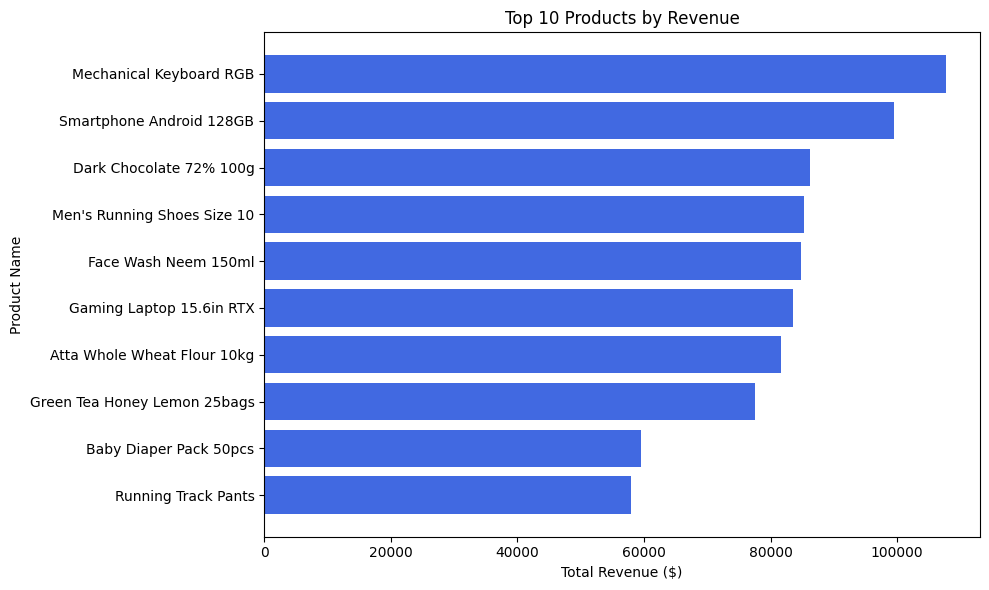

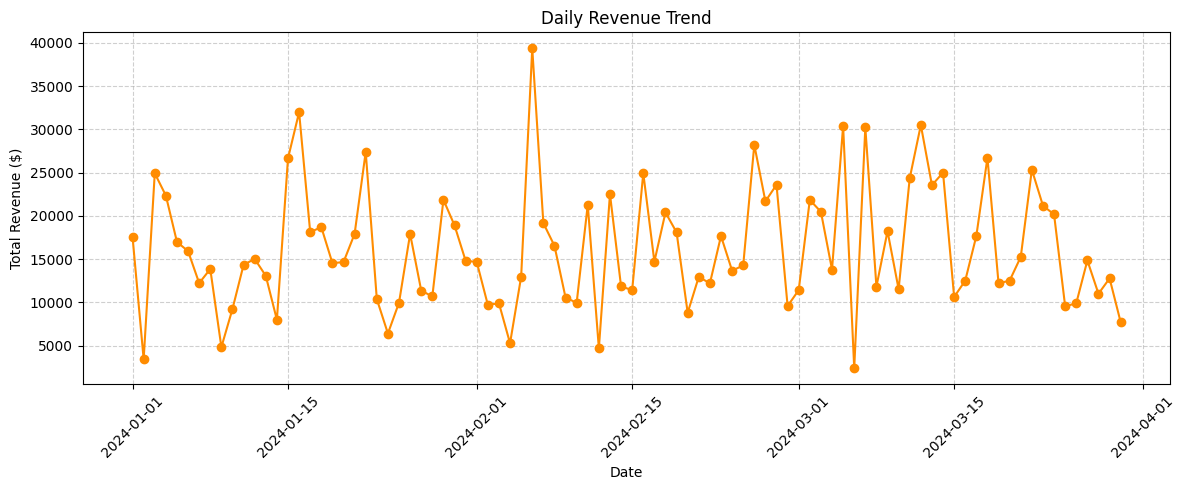

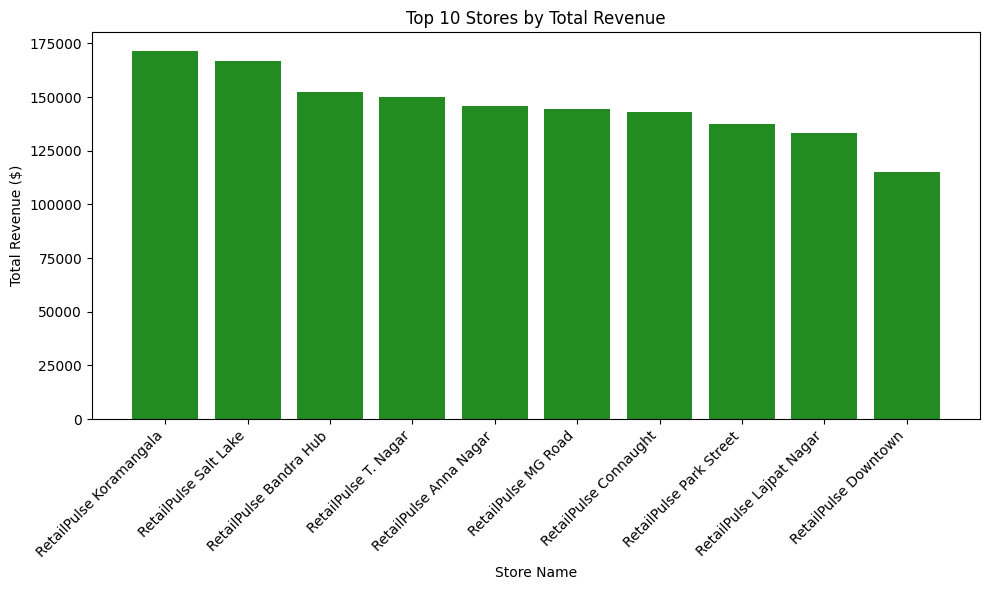

All visualisations generated and saved successfully.


In [0]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Chart 1: Horizontal Bar Chart - Top 10 Products by Revenue
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Sort ascending so the largest bar appears at the top of the horizontal chart
pdf_top_products_sorted = pdf_top_products.sort_values(by='total_revenue', ascending=True)

plt.barh(pdf_top_products_sorted['product_name'], pdf_top_products_sorted['total_revenue'], color='royalblue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Name')
plt.title('Top 10 Products by Revenue')
plt.tight_layout()
plt.savefig(f"{output_dir}chart1_top_products.png")
plt.show()

# ---------------------------------------------------------
# Chart 2: Line Chart - Daily Revenue Trend
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
# Ensure data is sorted by date for a proper line trend
pdf_daily_sales_sorted = pdf_daily_sales.sort_values(by='date')

plt.plot(pdf_daily_sales_sorted['date'], pdf_daily_sales_sorted['total_revenue'], marker='o', linestyle='-', color='darkorange')
plt.xlabel('Date')
plt.ylabel('Total Revenue ($)')
plt.title('Daily Revenue Trend')
plt.xticks(rotation=45) # Rotate dates for better readability
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f"{output_dir}chart2_daily_revenue.png")
plt.show()

# ---------------------------------------------------------
# Chart 3: Vertical Bar Chart - Store Performance
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.bar(pdf_store_perf['store_name'], pdf_store_perf['total_revenue'], color='forestgreen')
plt.xlabel('Store Name')
plt.ylabel('Total Revenue ($)')
plt.title('Top 10 Stores by Total Revenue')
plt.xticks(rotation=45, ha='right') # Rotate store names if they are long
plt.tight_layout()
plt.savefig(f"{output_dir}chart3_store_performance.png")
plt.show()

print("All visualisations generated and saved successfully.")